# Solución del laboratorio 1: Toyota: detectar una alteración del proceso
**Profesor de laboratorio: Manuel López.** Material docente.
Los resultados guardados corresponden a la ejecución del mismo código en Python. Abra el notebook desde esta carpeta para conservar las rutas relativas.
El desarrollo matemático, la interpretación y la pauta de corrección están en el archivo .tex asociado.


carta_p
 subgrupo  inspeccionadas  no_conformes       fase  proporcion  lcl_fijos  ucl_fijos  senal_fijos  lcl_reestimados  ucl_reestimados  senal_reestimados
        1              50             1 referencia        0.02        0.0   0.123138        False              0.0         0.160757              False
        2              50             2 referencia        0.04        0.0   0.123138        False              0.0         0.160757              False
        3              50             2 referencia        0.04        0.0   0.123138        False              0.0         0.160757              False
        4              50             3 referencia        0.06        0.0   0.123138        False              0.0         0.160757              False
        5              50             1 referencia        0.02        0.0   0.123138        False              0.0         0.160757              False
        6              50             3 referencia        0.06        0.0   0.123138 

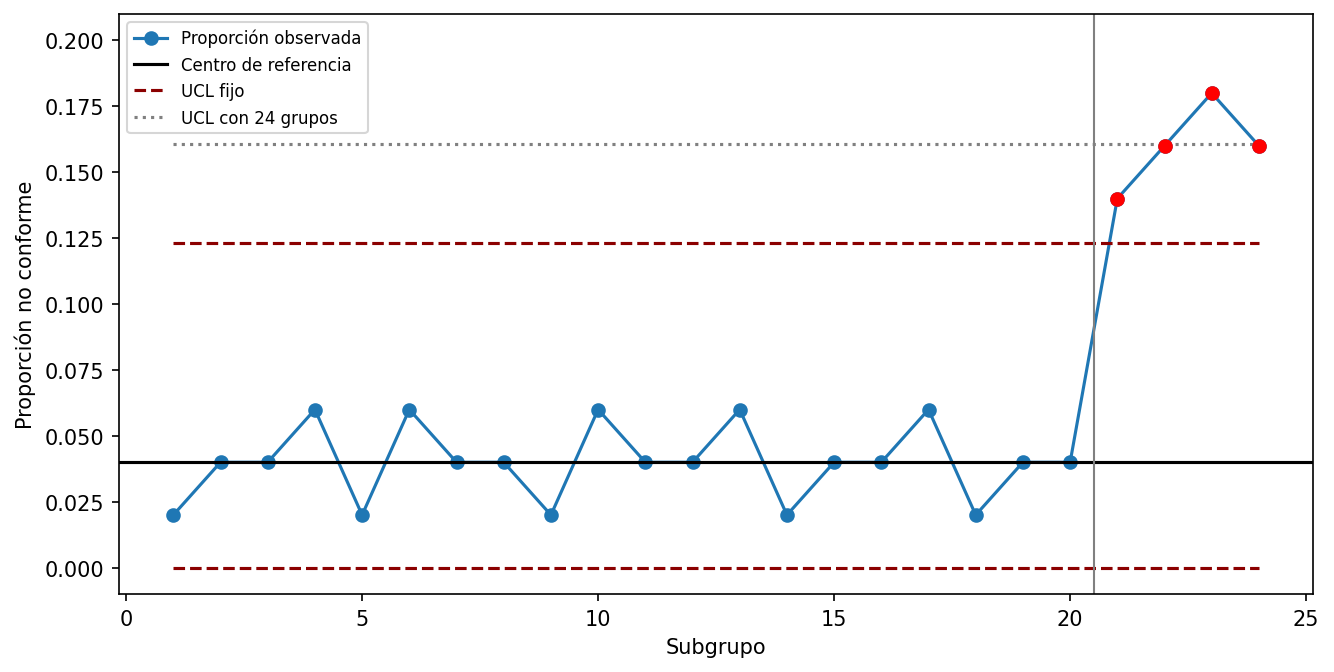

In [1]:
"""Solución docente de Gestión de Operaciones. Profesor: Manuel López."""
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
datos = base / "datos"
salida = base / "resultados"
salida.mkdir(exist_ok=True)
parametros = json.loads((datos / "parametros.json").read_text(encoding="utf-8"))

def tabla(df, nombre):
    df.to_csv(salida / (nombre + ".csv"), index=False)
    visible = df if len(df) <= 28 else df.head(12)
    print("\n" + nombre + "\n" + visible.to_string(index=False))
    if len(df) > 28:
        print(f"Vista inicial: {len(df)} filas completas en {nombre}.csv")

def figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(salida / (nombre + ".png"), dpi=150, bbox_inches="tight")
    if "__file__" not in globals():
        plt.show()
    plt.close(fig)

def resumen(obj):
    def convertir(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        raise TypeError(type(x))
    (salida / "resumen.json").write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=convertir),
        encoding="utf-8")

df = pd.read_csv(datos / "subgrupos.csv")
assert df["subgrupo"].is_unique
assert df["inspeccionadas"].gt(0).all()
assert df["no_conformes"].between(0, df["inspeccionadas"]).all()
ref = df["fase"].eq("referencia")
k = parametros["multiplicador_limites"]
p_ref = df.loc[ref, "no_conformes"].sum() / df.loc[ref, "inspeccionadas"].sum()
p_total = df["no_conformes"].sum() / df["inspeccionadas"].sum()
df["proporcion"] = df["no_conformes"] / df["inspeccionadas"]
for nombre, centro in [("fijos", p_ref), ("reestimados", p_total)]:
    ancho = k * np.sqrt(centro * (1-centro) / df["inspeccionadas"])
    df["lcl_"+nombre] = (centro-ancho).clip(lower=0)
    df["ucl_"+nombre] = (centro+ancho).clip(upper=1)
    df["senal_"+nombre] = (
        (df["proporcion"] < df["lcl_"+nombre]) |
        (df["proporcion"] > df["ucl_"+nombre]))
tabla(df, "carta_p")
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(df.subgrupo, df.proporcion, "o-", label="Proporción observada")
ax.axhline(p_ref, color="black", label="Centro de referencia")
ax.plot(df.subgrupo, df.ucl_fijos, "--", color="darkred", label="UCL fijo")
ax.plot(df.subgrupo, df.lcl_fijos, "--", color="darkred")
ax.plot(df.subgrupo, df.ucl_reestimados, ":", color="gray", label="UCL con 24 grupos")
ax.axvline(20.5, color="gray", linewidth=1)
se = df.senal_fijos
ax.scatter(df.loc[se,"subgrupo"], df.loc[se,"proporcion"], color="red", zorder=5)
ax.set(xlabel="Subgrupo", ylabel="Proporción no conforme", ylim=(-0.01,0.21))
ax.legend(fontsize=8, loc="upper left")
figura(fig,"carta_p")
assert np.isclose(p_ref,0.04)
assert df.loc[df.senal_fijos,"subgrupo"].tolist()==[21,22,23,24]
assert df.loc[df.senal_reestimados,"subgrupo"].tolist()==[23]
resumen({"p_ref":p_ref,"p_total":p_total,"ucl_ref":df.ucl_fijos.iloc[0],
         "ucl_total":df.ucl_reestimados.iloc[0],"senales_fijas":[21,22,23,24],
         "senales_reestimadas":[23]})
